In [2]:
import geopandas as gpd
import numpy as np

import pyogrio
import json
import base64

# ---- USER INPUTS ----
n = 5000
data_path = f"../dimension-reduction/data/{n}_sampled_classified_embeddings.geojson"


gdf = pyogrio.read_dataframe(data_path)

gdf["embedding"] = gdf["embedding"].apply(lambda v: json.loads(base64.b64decode(v)))

gdf.head()

,lat,lon,classification,embedding,umap_2d_x,umap_2d_y,umap_3d_x,umap_3d_y,umap_3d_z,tsne_2d_x,tsne_2d_y,tsne_3d_x,tsne_3d_y,tsne_3d_z,index_right,SOV_A3,subregion_code,subregion_name,geometry
0,50.923347,-95.882838,111,"[0.0629911572472126, -0.11909265667051133, 0.1...",30.397514,31.065041,-48.625294,-13.359444,25.846992,-44.728695,-31.155630,8.218651,-36.112946,20.101700,3.0,CAN,21.0,Northern America,POINT (-95.88284 50.92335)
1,52.679250,-86.519714,20,"[0.06698961937716265, -0.14769703960015382, 0....",32.567078,32.408348,-47.325607,-15.078400,24.067024,-43.387390,-30.026608,4.398693,-39.712151,19.019630,3.0,CAN,21.0,Northern America,POINT (-86.51971 52.67925)
2,53.338458,135.486148,116,"[0.024605920799692427, -0.19986159169550174, 0...",23.041275,29.906357,-43.227543,-0.662537,32.476822,-27.877193,-34.680862,8.374882,-16.270222,22.266945,18.0,RUS,151.0,Eastern Europe,POINT (135.48615 53.33846)
3,54.481250,17.594788,114,"[-0.15378700499807765, -0.024605920799692427, ...",30.136208,5.650921,-38.721985,-7.241364,-15.575645,-42.908031,-1.703259,-37.757370,-22.979420,0.552185,113.0,POL,151.0,Eastern Europe,POINT (17.59479 54.48125)
4,56.380259,125.083981,113,"[-0.08421376393694734, -0.186082276047674, -0....",25.197639,44.802513,-37.904243,-15.364410,39.480064,-8.465858,-42.491928,22.909531,-14.862144,-19.367918,18.0,RUS,151.0,Eastern Europe,POINT (125.08398 56.38026)


In [5]:
# Generate SVG drawings: umap.svg, tsne.svg, map.svg
import os
import matplotlib.pyplot as plt
import geopandas as gpd

os.makedirs("drawings", exist_ok=True)

# Ensure gdf exists and has required columns
required_cols = ["umap_2d_x", "umap_2d_y", "tsne_2d_x", "tsne_2d_y", "lat", "lon"]
missing = [c for c in required_cols if c not in gdf.columns]
if missing:
    raise ValueError(f"Missing required columns in gdf: {missing}")


# Helper: normalize series to 0..1
def normalize(s):
    s = s.astype(float)
    mn = s.min()
    mx = s.max()
    if mx == mn:
        return (s - mn) * 0.0
    return (s - mn) / (mx - mn)


# 1) UMAP scatter (transparent background, white points)
x = normalize(gdf["umap_2d_x"])
y = normalize(gdf["umap_2d_y"])  # keep aspect

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x, y, s=2, c="white", linewidths=0)
ax.set_axis_off()
fig.patch.set_alpha(0)
ax.set_facecolor("none")
plt.margins(0)
plt.savefig("drawings/umap.svg", transparent=True, bbox_inches="tight", pad_inches=0)
plt.close(fig)

# 2) t-SNE scatter (transparent background, white points)
x = normalize(gdf["tsne_2d_x"])
y = normalize(gdf["tsne_2d_y"])

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(x, y, s=2, c="white", linewidths=0)
ax.set_axis_off()
fig.patch.set_alpha(0)
ax.set_facecolor("none")
plt.margins(0)
plt.savefig("drawings/tsne.svg", transparent=True, bbox_inches="tight", pad_inches=0)
plt.close(fig)

# 3) Map: world basemap with white points at lon/lat (transparent background)
# Create a GeoDataFrame for points (ensure EPSG:4326)
points_gdf = gpd.GeoDataFrame(
    gdf[["lon", "lat"]].copy(),
    geometry=gpd.points_from_xy(gdf["lon"], gdf["lat"]),
    crs="EPSG:4326",
)

# Load a low-res world map and project both to Web Mercator for nicer aspect
# world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
# world = world.to_crs("EPSG:3857")
points_proj = points_gdf.to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(12, 6))
# # Draw countries as very light gray outlines, no fill (transparent background)
# world.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.3)

# Plot points in white; adjust size so they are visible on map
points_proj.plot(ax=ax, markersize=2, color="white", linewidth=0)

ax.set_axis_off()
fig.patch.set_alpha(0)
ax.set_facecolor("none")
plt.tight_layout(pad=0)
plt.savefig("drawings/map.svg", transparent=True, bbox_inches="tight", pad_inches=0)
plt.close(fig)

print("Saved: drawings/umap.svg, drawings/tsne.svg, drawings/map.svg")

Saved: drawings/umap.svg, drawings/tsne.svg, drawings/map.svg


SVG saved as: drawings/remote_sensing_papers.svg


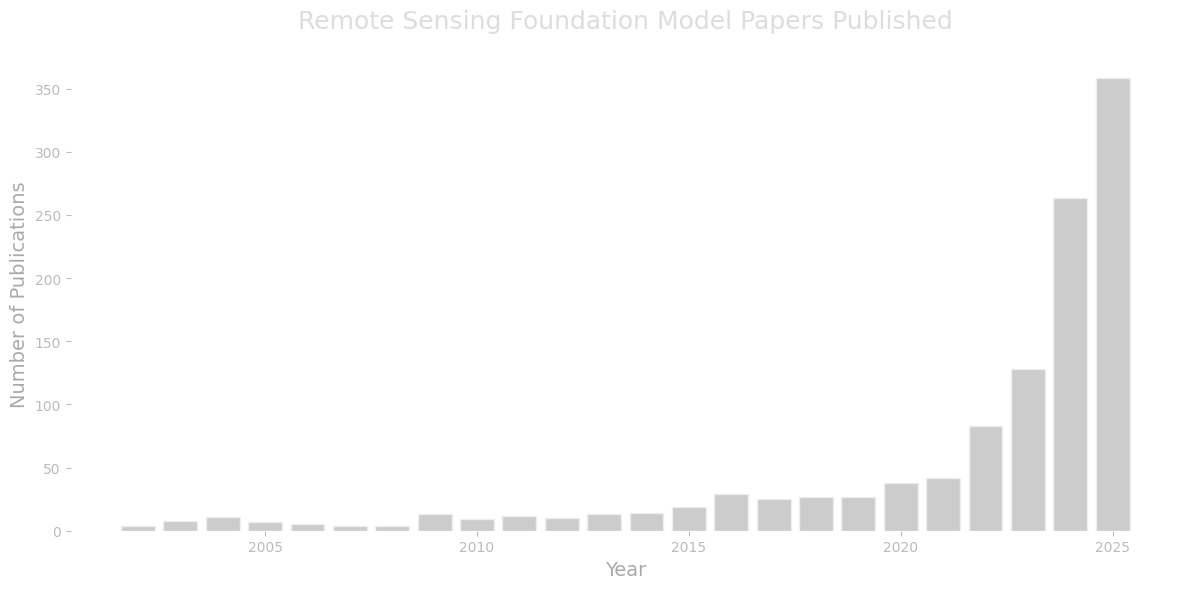

In [9]:
import matplotlib.pyplot as plt

# -------------------------------
# Data
# -------------------------------
years = [
    2002,
    2003,
    2004,
    2005,
    2006,
    2007,
    2008,
    2009,
    2010,
    2011,
    2012,
    2013,
    2014,
    2015,
    2016,
    2017,
    2018,
    2019,
    2020,
    2021,
    2022,
    2023,
    2024,
    2025,
]

counts = [
    4,
    8,
    11,
    7,
    5,
    4,
    4,
    13,
    9,
    12,
    10,
    13,
    14,
    19,
    29,
    25,
    27,
    27,
    38,
    42,
    83,
    128,
    263,
    358,
]

# -------------------------------
# Plot styling
# -------------------------------
plt.style.use("default")
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# Transparent background
fig.patch.set_alpha(0.0)
ax.set_facecolor((0, 0, 0, 0))

# Bars (gray-white tone)
ax.bar(years, counts, color="#CCCCCC", edgecolor="#EEEEEE")

# Title
ax.set_title(
    "Remote Sensing Foundation Model Papers Published",
    color="#DDDDDD",
    fontsize=18,
    pad=20,
)

# Axis labels
ax.set_xlabel("Year", color="#AAAAAA", fontsize=14)
ax.set_ylabel("Number of Publications", color="#AAAAAA", fontsize=14)

# Axis ticks
ax.tick_params(colors="#BBBBBB", labelsize=10)

# Remove chart spines (cleaner look)
for spine in ax.spines.values():
    spine.set_visible(False)

# Tight layout for nicer spacing
plt.tight_layout()

# -------------------------------
# Export as SVG
# -------------------------------
output_file = "drawings/remote_sensing_papers.svg"
plt.savefig(output_file, format="svg", transparent=True)

print(f"SVG saved as: {output_file}")